## klasifikasi gangguan jaringan iomino

### Import

In [1]:
import os
import json
import warnings

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    learning_curve,
    cross_val_score
)

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc,
    silhouette_score
)

import joblib

warnings.filterwarnings("ignore")

sns.set(style="darkgrid")

print("Library berhasil dimuat")

Library berhasil dimuat


## SETUP FOLDER

In [2]:
BASE_DIR = os.getcwd()

STATIC_DIR = os.path.join(BASE_DIR, "static")
MODELS_DIR = os.path.join(BASE_DIR, "models")

os.makedirs(STATIC_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

def save_plot(filename):
    plt.tight_layout()
    plt.savefig(
        os.path.join(STATIC_DIR, filename),
        dpi=150,
        bbox_inches="tight"
    )
    plt.close()

### Business Understanding

Dalam proses monitoring jaringan, data yang dihasilkan umumnya masih berbentuk log teknis yang sulit dipahami secara langsung oleh operator maupun pengambil keputusan. Data tersebut memuat berbagai informasi seperti throughput, delay komunikasi, jumlah paket, hingga durasi koneksi.

Permasalahan utama muncul ketika data yang sangat teknis tersebut harus diterjemahkan menjadi kondisi jaringan yang lebih mudah dipahami, misalnya apakah jaringan sedang berada dalam kondisi normal atau mengalami gangguan.

Melalui notebook ini, dilakukan pembangunan sistem klasifikasi kualitas jaringan menggunakan pendekatan machine learning dengan fokus pada empat parameter utama, yaitu bandwidth, latency, packet loss, dan uptime.

Model yang dibangun nantinya akan diintegrasikan ke dalam aplikasi berbasis Flask sehingga proses prediksi dapat dilakukan secara real-time melalui antarmuka web.

### LOAD DATA

In [3]:
data_path = os.path.join(BASE_DIR, "output_flow_1.1unp.csv")

df_raw = pd.read_csv(data_path, sep=';')

print("Data berhasil dibaca")
print("Ukuran dataset:", df_raw.shape)

display(df_raw.head())

print("\nInfo dataset:")
df_raw.info()

Data berhasil dibaca
Ukuran dataset: (5819, 29)


,protocol,start_time,end_time,duration_seconds,total_packets,forward_packets,backward_packets,is_bidirectional,forward_backward_ratio,total_bytes,...,avg_packet_size,avg_inter_arrival_ms,min_inter_arrival_ms,max_inter_arrival_ms,tcp_flags,syn_count,fin_count,rst_count,ack_count,connection_state
0,UDP,2026-04-29 15:45:27.933591,2026-04-29 15:46:10.233500,42.299.909,21209,2249,18960,True,0.11861814345991561,24059374,...,11.343.945.494.837.000,19.945.260.750.660.100,-0.091,25.641.489,NaN,0,0,0,0,Unknown
1,TCP,2026-04-29 14:56:37.159573,2026-04-29 14:57:10.726682,33.567.109,6956,4481,2475,True,18.105.050.505.050.500,6374307,...,9.163.753.594.019.550,4.826.327.677.929.540,-0.004,14.138.509.999.999.900,"A,FA,PA,RA,S,SA",1,2,1,6955,Closed
2,TCP,2026-04-29 15:50:09.578485,2026-04-29 15:53:41.758948,212.180.463,3837,552,3285,True,0.1680365296803653,4991415,...,13.008.639.562.157.900,55.312.946.558.915.500,0.0,61.625.391,"A,FA,PA,S,SA",1,2,0,3836,Closed
3,UDP,2026-04-29 15:30:02.366193,2026-04-29 15:30:14.934230,12.568.037,3977,525,3452,True,0.15208574739281575,4308051,...,108.324.138.798.089,3.160.975.100.603.620,-0.04,4.819.866,NaN,0,0,0,0,Unknown
4,UDP,2026-04-29 15:30:02.391197,2026-04-29 15:30:10.197485,7.806.288,2598,346,2252,True,0.15364120781527532,2832963,...,10.904.399.538.106.200,300.588.679.245.283,-0.037,3.865.801,NaN,0,0,0,0,Unknown



Info dataset:
<class 'pandas.DataFrame'>
RangeIndex: 5819 entries, 0 to 5818
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   protocol                5819 non-null   str  
 1   start_time              5819 non-null   str  
 2   end_time                5819 non-null   str  
 3   duration_seconds        5819 non-null   str  
 4   total_packets           5819 non-null   int64
 5   forward_packets         5819 non-null   int64
 6   backward_packets        5819 non-null   int64
 7   is_bidirectional        5819 non-null   bool 
 8   forward_backward_ratio  5819 non-null   str  
 9   total_bytes             5819 non-null   int64
 10  forward_bytes           5819 non-null   int64
 11  backward_bytes          5819 non-null   int64
 12  total_payload_bytes     5819 non-null   int64
 13  forward_payload_bytes   5819 non-null   int64
 14  backward_payload_bytes  5819 non-null   int64
 15  packets_per_secon

### Data Understanding

Dataset yang digunakan merupakan data monitoring jaringan yang masih berada dalam kondisi mentah. Pada tahap awal ini dilakukan proses identifikasi struktur data untuk memahami karakteristik atribut yang tersedia sebelum masuk ke proses analisis lebih lanjut.

Tahap ini penting karena kualitas pemahaman terhadap data akan sangat mempengaruhi kualitas feature engineering maupun proses modeling yang dilakukan setelahnya.

In [4]:
# Shape dataset
df_raw.shape

(5819, 29)

Jumlah observasi pada dataset menunjukkan bahwa data monitoring memiliki volume yang cukup untuk dilakukan proses pembelajaran model machine learning.

Banyaknya observasi akan membantu model dalam mempelajari pola performa jaringan secara lebih stabil.

In [5]:
# Statistik deskriptif
df_raw.describe(include="all")

,protocol,start_time,end_time,duration_seconds,total_packets,forward_packets,backward_packets,is_bidirectional,forward_backward_ratio,total_bytes,...,avg_packet_size,avg_inter_arrival_ms,min_inter_arrival_ms,max_inter_arrival_ms,tcp_flags,syn_count,fin_count,rst_count,ack_count,connection_state
count,5819,5819,5819,5819,5819.000000,5819.000000,5819.000000,5819,5819,5.819000e+03,...,5819,5819,5819,5819,693,5819.000000,5819.000000,5819.000000,5819.000000,5819
unique,5,5633,5536,2694,NaN,NaN,NaN,2,358,NaN,...,1334,2694,1648,2690,26,NaN,NaN,NaN,NaN,5
top,UDP,2026-04-29 15:18:41.442762,2026-04-29 14:56:26.449480,0.0,NaN,NaN,NaN,False,inf,NaN,...,594.0,0.0,0.0,0.0,"A,FA,PA,S,SA",NaN,NaN,NaN,NaN,Unknown
freq,4663,5,7,3097,NaN,NaN,NaN,4131,3780,NaN,...,2031,3097,4092,3097,352,NaN,NaN,NaN,NaN,5126
mean,NaN,NaN,NaN,NaN,34.162743,16.592714,17.570029,NaN,NaN,2.209458e+04,...,NaN,NaN,NaN,NaN,NaN,0.121155,0.227015,0.051383,12.062554,NaN
std,NaN,NaN,NaN,NaN,359.179921,146.544620,280.562158,NaN,NaN,3.611016e+05,...,NaN,NaN,NaN,NaN,NaN,0.375327,0.831148,0.306803,161.291873,NaN
min,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000,NaN,NaN,4.200000e+01,...,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,1.000000,1.000000,0.000000,NaN,NaN,1.880000e+02,...,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN
50%,NaN,NaN,NaN,NaN,1.000000,1.000000,0.000000,NaN,NaN,5.940000e+02,...,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN
75%,NaN,NaN,NaN,NaN,7.000000,6.000000,1.000000,NaN,NaN,9.230000e+02,...,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN


Statistik deskriptif memberikan gambaran awal mengenai pola distribusi data, sebaran nilai, serta potensi adanya nilai ekstrem pada beberapa atribut jaringan.

Tahap ini membantu dalam memahami perilaku dasar data sebelum dilakukan pembersihan dan transformasi lebih lanjut.

### DATA CLEANING

In [10]:
def clean_number(x):
    try:
        return float(str(x).replace(".", "").replace(",", "."))
    except:
        return np.nan

In [11]:
numeric_cols = [
    "bytes_per_second",
    "avg_inter_arrival_ms",
    "forward_packets",
    "backward_packets",
    "total_packets",
    "duration_seconds"
]

df = df_raw.copy()

for col in numeric_cols:
    df[col] = df[col].apply(clean_number)

### Data Cleaning

Tahap pembersihan data dilakukan karena format numerik pada dataset masih belum konsisten. Beberapa nilai numerik masih tersimpan sebagai string sehingga tidak dapat langsung diproses oleh model machine learning.

Proses konversi dilakukan untuk memastikan seluruh atribut numerik dapat dianalisis secara matematis tanpa menyebabkan error pada tahap modeling.

In [12]:
# Missing value
missing_values = df.isnull().sum()

missing_values

protocol                     0
start_time                   0
end_time                     0
duration_seconds             0
total_packets                0
forward_packets              0
backward_packets             0
is_bidirectional             0
forward_backward_ratio       0
total_bytes                  0
forward_bytes                0
backward_bytes               0
total_payload_bytes          0
forward_payload_bytes        0
backward_payload_bytes       0
packets_per_second           0
bytes_per_second             0
min_packet_size              0
max_packet_size              0
avg_packet_size              0
avg_inter_arrival_ms         0
min_inter_arrival_ms         0
max_inter_arrival_ms         0
tcp_flags                 5126
syn_count                    0
fin_count                    0
rst_count                    0
ack_count                    0
connection_state             0
dtype: int64

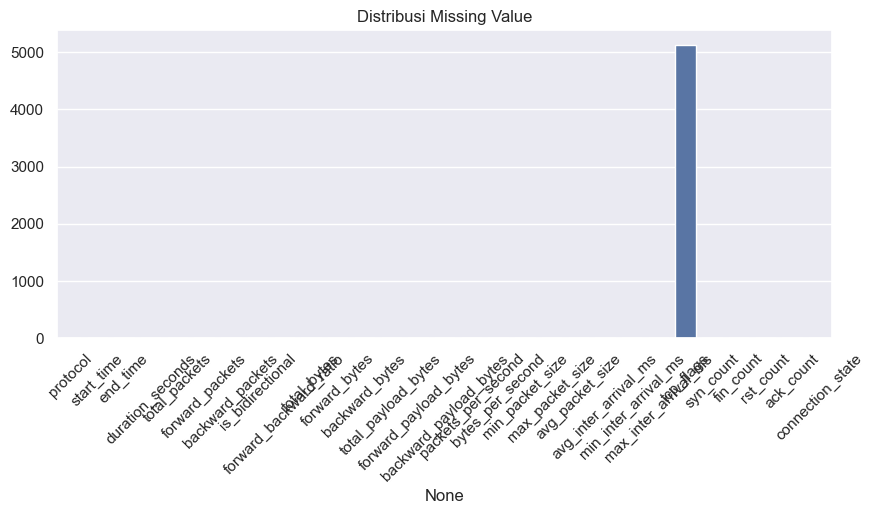

In [13]:
plt.figure(figsize=(10,4))

sns.barplot(
    x=missing_values.index,
    y=missing_values.values
)

plt.xticks(rotation=45)
plt.title("Distribusi Missing Value")

plt.savefig("missing_values.png")
plt.show()

Nilai yang hilang ditangani menggunakan median karena metode ini lebih stabil terhadap outlier dibandingkan rata-rata.

Pendekatan ini dipilih untuk menjaga karakteristik distribusi data jaringan tetap mendekati kondisi aslinya.

# FEATURE ENGINEERING

In [14]:
df_fe = pd.DataFrame()

df_fe["bandwidth"] = df["bytes_per_second"] / 1_000_000

df_fe["latency"] = df["avg_inter_arrival_ms"]

df_fe["packet_loss"] = (
    abs(df["forward_packets"] - df["backward_packets"])
    / (df["total_packets"] + 1e-6)
) * 100

df_fe["uptime"] = (
    df["duration_seconds"]
    / df["duration_seconds"].max()
) * 100

df_fe.head()

,bandwidth,latency,packet_loss,uptime
0,5.687808e+09,1.994526e+16,78.792022,0.962141
1,1.898974e+10,4.826328e+15,28.838413,0.763508
2,2.352439e+10,5.531295e+16,71.227521,4.826194
3,3.427784e+09,3.160975e+15,73.598190,0.285869
4,3.629078e+10,3.005887e+14,73.364126,0.177560


Keempat Variabel ini saya pilih sebagai paramter utama dalam perhitungan gangguan jaringan berdasarkan spesifikasi tolok ukur utama dalam pemilihan fitur yang menemukan label

In [15]:
df_fe.info()

<class 'pandas.DataFrame'>
RangeIndex: 5819 entries, 0 to 5818
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   bandwidth    5819 non-null   float64
 1   latency      5819 non-null   float64
 2   packet_loss  5819 non-null   float64
 3   uptime       5819 non-null   float64
dtypes: float64(4)
memory usage: 182.0 KB


In [17]:
print(df_fe.duplicated().sum())

3098


In [18]:
df_fe.isnull().sum()

bandwidth      0
latency        0
packet_loss    0
uptime         0
dtype: int64

### Histrogram

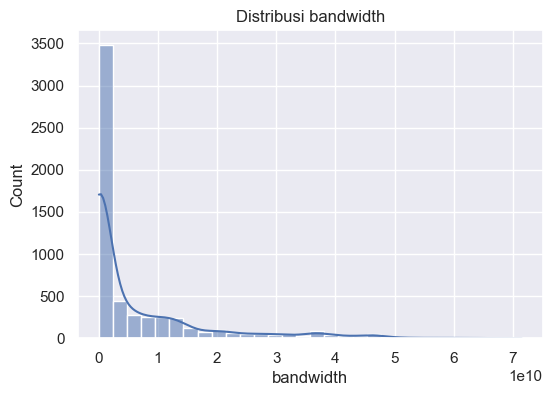

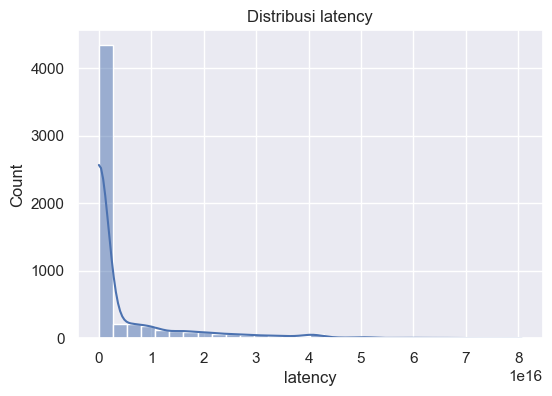

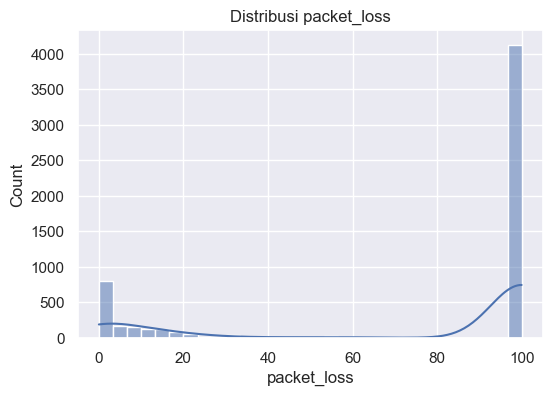

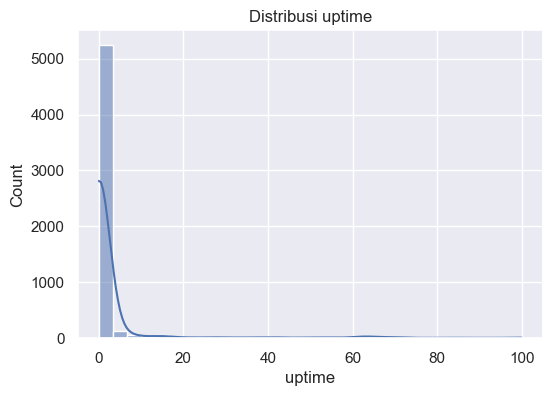

In [19]:
features = [
    "bandwidth",
    "latency",
    "packet_loss",
    "uptime"
]

for col in features:

    plt.figure(figsize=(6,4))

    sns.histplot(
        df_fe[col],
        kde=True,
        bins=30
    )

    plt.title(f"Distribusi {col}")
    plt.show()
    save_plot(f"hist_{col}.png")

Histogram digunakan untuk memahami pola distribusi setiap fitur jaringan.

Melalui visualisasi ini dapat terlihat bahwa beberapa parameter memiliki distribusi yang tidak simetris. Dalam konteks jaringan, kondisi tersebut sering muncul akibat adanya lonjakan trafik atau ketidakstabilan komunikasi penggunaan jaringan pada waktu tertentu.

### Scaling Cluster

In [20]:
scaler_cluster = StandardScaler()

X_cluster = scaler_cluster.fit_transform(
    df_fe[features]
)

### Clustering Menggunakan K-Means

In [21]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_cluster)

df_fe["cluster"] = clusters

df_fe.head()

,bandwidth,latency,packet_loss,uptime,cluster
0,5.687808e+09,1.994526e+16,78.792022,0.962141,1
1,1.898974e+10,4.826328e+15,28.838413,0.763508,1
2,2.352439e+10,5.531295e+16,71.227521,4.826194,1
3,3.427784e+09,3.160975e+15,73.598190,0.285869,0
4,3.629078e+10,3.005887e+14,73.364126,0.177560,1


Pendekatan clustering ini saya gunakan untuk membentuk pola alami pada data sebelum proses klasifikasi dilakukan.

Berbeda dengan pendekatan rule-based labeling langsung, clustering memungkinkan proses segmentasi data dilakukan berdasarkan kombinasi karakteristik jaringan secara keseluruhan. Pendekatan ini membantu mengurangi risiko data leakage dan overfitting pada model machine learning.

In [22]:
sil_score = silhouette_score(
    X_cluster,
    clusters
)

print("Silhouette Score:", sil_score)

Silhouette Score: 0.5876195972409358


Silhouette Score digunakan untuk mengevaluasi kualitas pembentukan cluster. Nilai yang lebih tinggi menunjukkan bahwa masing-masing cluster memiliki pemisahan yang lebih baik dan tidak terlalu saling tumpang tindih.

Evaluasi clustering penting dilakukan untuk memastikan bahwa proses segmentasi data benar-benar membentuk pola yang bermakna dan mendapatkan insight.

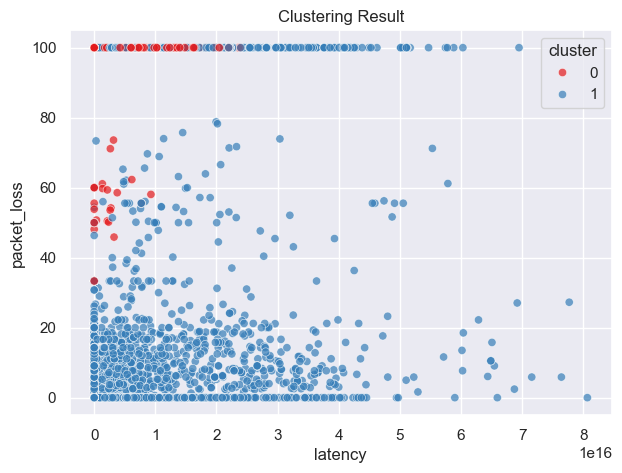

In [23]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df_fe,
    x="latency",
    y="packet_loss",
    hue="cluster",
    palette="Set1",
    alpha=0.7
)

plt.title("Clustering Result")
plt.show()
save_plot("cluster_scatter.png")

Visualisasi clustering memperlihatkan bahwa data jaringan mulai membentuk pola segmentasi berdasarkan karakteristik performa jaringan.

Pemisahan cluster ini menunjukkan bahwa data memiliki variasi perilaku yang cukup untuk digunakan dalam proses klasifikasi machine learning.

In [24]:
cluster_summary = df_fe.groupby("cluster")[features].mean()

cluster_summary

,bandwidth,latency,packet_loss,uptime
cluster,,,,
0,7.995945e+08,4.809127e+14,99.714108,0.609736
1,1.513582e+10,1.099018e+16,32.278790,8.314528


In [26]:
severity_df = df_fe.copy()

# Normalisasi 

severity_df["latency_score"] = (
    severity_df["latency"]
    /
    severity_df["latency"].max()
) * 100

severity_df["packet_loss_score"] = (
    severity_df["packet_loss"]
    /
    severity_df["packet_loss"].max()
) * 100

severity_df["uptime_score"] = (
    100 -
    (
        severity_df["uptime"]
        /
        severity_df["uptime"].max()
    ) * 100
)

severity_df["bandwidth_score"] = (
    100 -
    (
        severity_df["bandwidth"]
        /
        severity_df["bandwidth"].max()
    ) * 100
)

### Final Serevity Score

In [27]:
severity_df["severity_score"] = (

    (severity_df["latency_score"] * 0.40)

    +

    (severity_df["packet_loss_score"] * 0.40)

    +

    (severity_df["uptime_score"] * 0.15)

    +

    (severity_df["bandwidth_score"] * 0.05)

)

severity_df[[
    "bandwidth",
    "latency",
    "packet_loss",
    "uptime",
    "severity_score"
]].head()

,bandwidth,latency,packet_loss,uptime,severity_score
0,5.687808e+09,1.994526e+16,78.792022,0.962141,60.865242
1,1.898974e+10,4.826328e+15,28.838413,0.763508,32.485888
2,2.352439e+10,5.531295e+16,71.227521,4.826194,73.550606
3,3.427784e+09,3.160975e+15,73.598190,0.285869,50.724121
4,3.629078e+10,3.005887e+14,73.364126,0.177560,46.929664


Severity score dibangun menggunakan kombinasi beberapa parameter performa jaringan dengan bobot yang berbeda sesuai tingkat pengaruhnya terhadap kualitas jaringan.

Latency dan packet loss diberikan bobot lebih besar karena kedua parameter tersebut memiliki pengaruh paling signifikan terhadap stabilitas komunikasi jaringan.

Sementara itu bandwidth dan uptime tetap digunakan sebagai parameter pendukung untuk membantu model memahami kondisi jaringan secara lebih menyeluruh.

In [28]:
severity_df.groupby("cluster")[[
    "bandwidth",
    "latency",
    "packet_loss",
    "uptime",
    "severity_score"
]].mean()

,bandwidth,latency,packet_loss,uptime,severity_score
cluster,,,,,
0,7.995945e+08,4.809127e+14,99.714108,0.609736,59.976733
1,1.513582e+10,1.099018e+16,32.278790,8.314528,36.055527


### Labeling Menggunakan Quantile dan Berdasarkan Severity Score

Dari Hasil Clustering

In [29]:
# ============================================================
# LABELING — Quantile + Severity Jitter
# Zona transisi diperlebar dengan noise pada severity_score
# agar model tidak bisa membaca boundary secara sempurna
# ============================================================

np.random.seed(42)

# Tambahkan jitter proporsional ke severity_score
# untuk menyebarkan mass point di nilai 60.0
_noise_scale = severity_df["severity_score"].std() * 0.35
_severity_jittered = (
    severity_df["severity_score"]
    + np.random.normal(0, _noise_scale, len(severity_df))
)

# Threshold berdasarkan distribusi yang sudah di-jitter
q_low  = _severity_jittered.quantile(0.35)
q_high = _severity_jittered.quantile(0.65)

labels = []

for score in _severity_jittered:

    # Zona Bawah → Normal
    if score <= q_low:
        labels.append("normal")

    # Zona Atas → Gangguan
    elif score >= q_high:
        labels.append("gangguan")

    # Zona Transisi — ambiguous boundary
    else:
        midpoint = (q_low + q_high) / 2
        if score >= midpoint:
            labels.append("gangguan")
        else:
            labels.append("normal")

# Finalisasi Label
severity_df["label"] = labels

# Distribusi Label
print(severity_df["label"].value_counts())
print(severity_df["label"].value_counts(normalize=True).round(3))

label
gangguan    3106
normal      2713
Name: count, dtype: int64
label
gangguan    0.534
normal      0.466
Name: proportion, dtype: float64


In [30]:
severity_df.head()

,bandwidth,latency,packet_loss,uptime,cluster,latency_score,packet_loss_score,uptime_score,bandwidth_score,severity_score,label
0,5.687808e+09,1.994526e+16,78.792022,0.962141,1,24.726490,78.792022,99.037859,92.043164,60.865242,gangguan
1,1.898974e+10,4.826328e+15,28.838413,0.763508,1,5.983283,28.838413,99.236492,73.434709,32.485888,normal
2,2.352439e+10,5.531295e+16,71.227521,4.826194,1,68.572432,71.227521,95.173806,67.091065,73.550606,gangguan
3,3.427784e+09,3.160975e+15,73.598190,0.285869,0,3.918716,73.598190,99.714131,95.204776,50.724121,gangguan
4,3.629078e+10,3.005887e+14,73.364126,0.177560,1,0.372645,73.364126,99.822440,49.231787,46.929664,normal


In [31]:
severity_df[[
    "latency",
    "packet_loss",
    "uptime",
    "bandwidth",
    "severity_score"
]].corr()

,latency,packet_loss,uptime,bandwidth,severity_score
latency,1.000000,-0.299739,0.148112,0.304603,-0.028743
packet_loss,-0.299739,1.000000,0.077706,-0.351236,0.952793
uptime,0.148112,0.077706,1.000000,0.144461,-0.008462
bandwidth,0.304603,-0.351236,0.144461,1.000000,-0.335946
severity_score,-0.028743,0.952793,-0.008462,-0.335946,1.000000


Tahap interpretasi cluster dilakukan untuk memahami karakteristik masing-masing kelompok data jaringan.

Cluster dengan latency lebih tinggi, packet loss lebih besar, dan bandwidth lebih rendah akan diinterpretasikan sebagai kondisi gangguan. Sementara cluster dengan performa jaringan lebih stabil akan dikategorikan sebagai kondisi normal.

### Exploratory Analysis Data

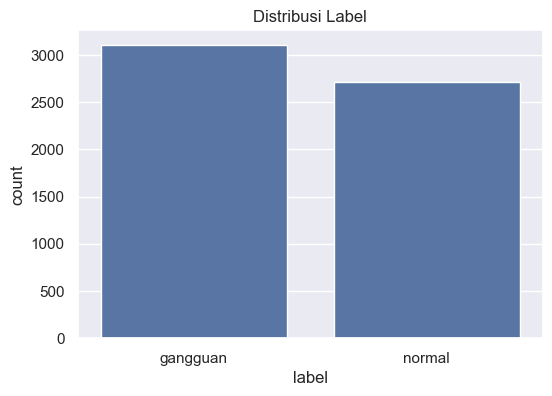

In [32]:
plt.figure(figsize=(6,4))

sns.countplot(x=severity_df["label"])

plt.title("Distribusi Label")
plt.show()
save_plot("label_distribution.png")

### Boxplot


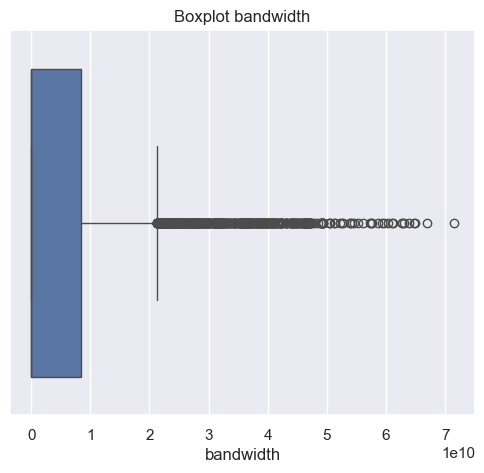

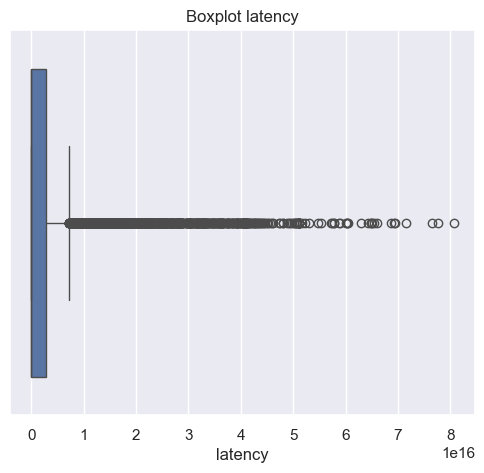

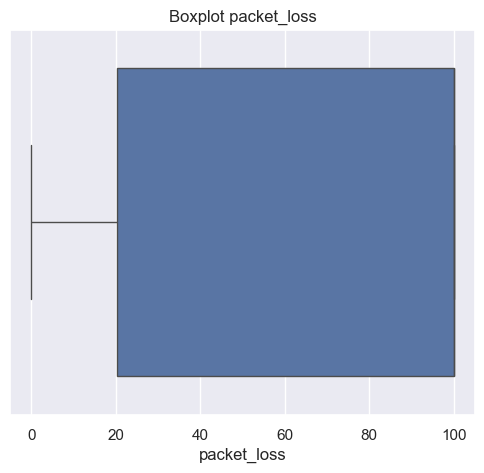

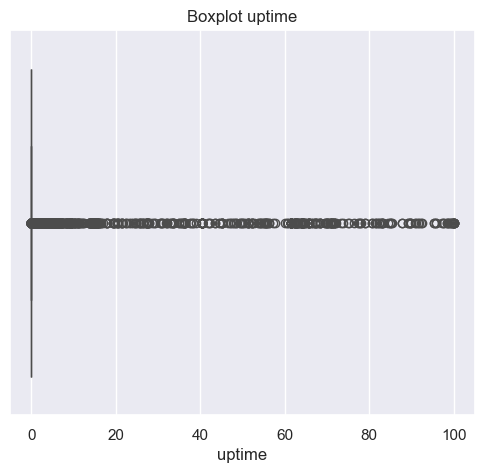

In [33]:
for col in features:

    plt.figure(figsize=(6,5))

    sns.boxplot(x=df_fe[col])

    plt.title(f"Boxplot {col}")
    plt.show()

    save_plot(f"boxplot_{col}.png")

Visualisasi boxplot memperlihatkan adanya beberapa nilai ekstrem pada sejumlah parameter jaringan.

Nilai ekstrem pada data capturing tidak selalu dianggap sebagai noise. Dalam beberapa kasus, kondisi tersebut justru dapat merepresentasikan gangguan jaringan yang benar-benar terjadi pada lingkungan gedung kantor operasional.

### Heatmap korelasi

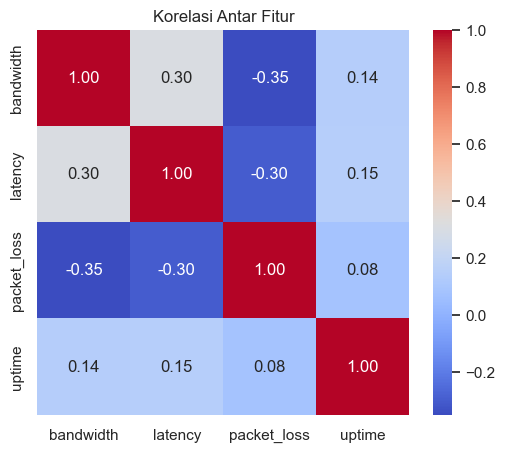

In [34]:
plt.figure(figsize=(6,5))

corr = severity_df[features].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Korelasi Antar Fitur")
plt.show()
save_plot("correlation_heatmap.png")

Heatmap korelasi digunakan untuk memahami hubungan antar parameter jaringan.

Hubungan antar fitur penting untuk dianalisis karena beberapa algoritma machine learning memiliki sensitivitas terhadap fitur yang saling berkorelasi tinggi. Selain itu, korelasi juga membantu memahami perilaku performa jaringan secara lebih menyeluruh.

### KDE berdasarkan label

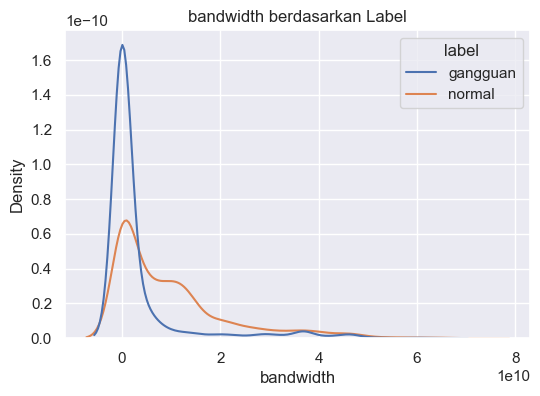

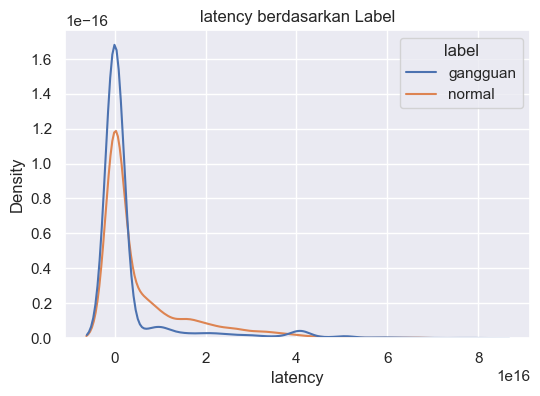

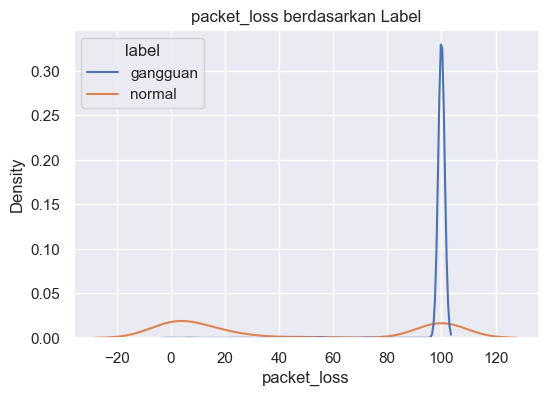

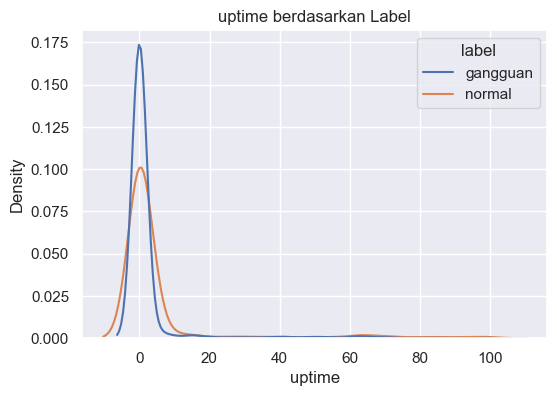

In [35]:
for col in features:

    plt.figure(figsize=(6,4))

    sns.kdeplot(
        data=severity_df,
        x=col,
        hue="label",
        common_norm=False
    )

    plt.title(f"{col} berdasarkan Label")
    plt.show()

    save_plot(f"kde_{col}.png")

Distribusi fitur berdasarkan label memperlihatkan bahwa kondisi normal dan gangguan memiliki pola sebaran yang berbeda pada beberapa parameter jaringan.

Perbedaan pola tersebut menjadi indikasi bahwa fitur yang dibentuk memiliki kemampuan untuk membantu model dalam membedakan kondisi jaringan secara lebih efektif.

### Scatter plot 1

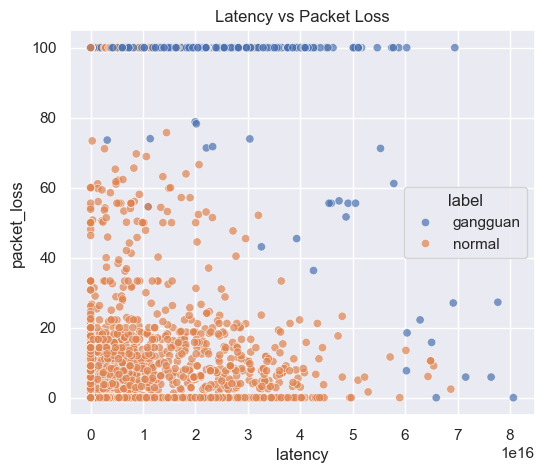

In [36]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=severity_df,
    x="latency",
    y="packet_loss",
    hue="label",
    alpha=0.7
)

plt.title("Latency vs Packet Loss")
plt.show()
save_plot("scatter_latency_packetloss.png")

Scatter plot memperlihatkan bahwa peningkatan latency sering kali diikuti dengan kenaikan packet loss pada sejumlah observasi jaringan.

Pola ini menunjukkan bahwa keterlambatan komunikasi dan ketidakstabilan transmisi data memiliki hubungan yang cukup erat dalam merepresentasikan kondisi gangguan jaringan.

### Scatter plot 2

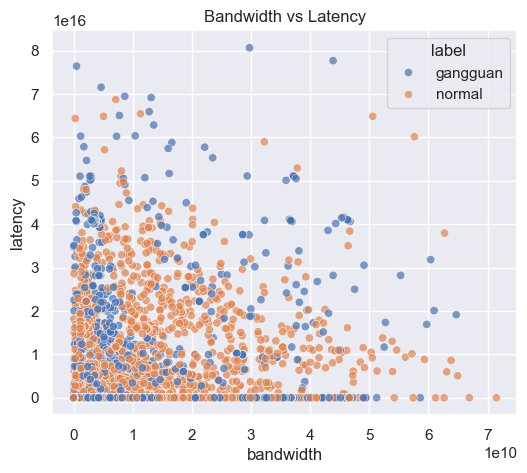

In [37]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=severity_df,
    x="bandwidth",
    y="latency",
    hue="label",
    alpha=0.7
)

plt.title("Bandwidth vs Latency")
plt.show()
save_plot("scatter_bandwidth_latency.png")

Visualisasi bandwidth dan latency menunjukkan bahwa koneksi dengan bandwidth rendah cenderung memiliki latency yang lebih tinggi dibandingkan koneksi yang stabil.

Fenomena ini menggambarkan bagaimana keterbatasan throughput dapat mempengaruhi kualitas komunikasi jaringan secara keseluruhan.

### Scatter plot 3


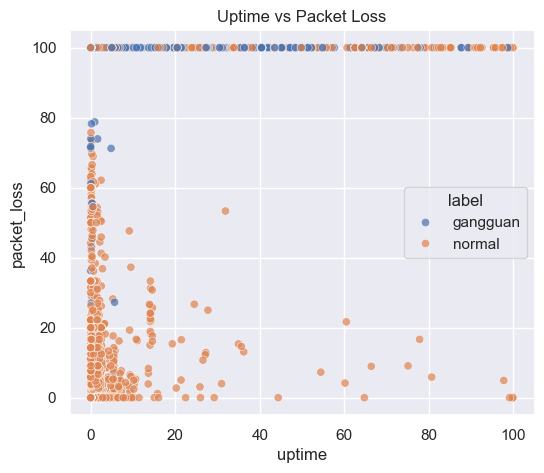

In [38]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=severity_df,
    x="uptime",
    y="packet_loss",
    hue="label",
    alpha=0.7
)

plt.title("Uptime vs Packet Loss")
plt.show()
save_plot("scatter_uptime_packetloss.png")

### DATA PREPARATION UNTUK MODELING

In [41]:
features = [
    "bandwidth",
    "latency",
    "packet_loss",
    "uptime"
]
x = severity_df[features]

y = severity_df["label"]

le = LabelEncoder()

y_enc = le.fit_transform(y)


print(y.value_counts())

label
gangguan    3106
normal      2713
Name: count, dtype: int64


### Split training & test

In [42]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y_enc,
    test_size=0.2,
    stratify=y_enc,
    random_state=42
)

### Scaler

In [43]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

Data Preparation

Dataset ini dipisahkan menjadi data training dan testing agar proses evaluasi dapat dilakukan secara objektif.

Selain itu, dilakukan proses scaling untuk menyeimbangkan rentang nilai antar fitur sehingga model dapat mempelajari pola data secara lebih optimal.

### Modeling 

Menggunakan Implmentasi Model Algoritma Random Forest & Naive Bayes

##### Implementasi Algoritma Random Forest

In [44]:
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [3, 5, 7],
    "min_samples_split": [10, 20, 30],
    "min_samples_leaf": [5, 10, 15],
    "max_features": ["sqrt"]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42
    ),

    param_grid=param_grid,

    cv=5,

    scoring="f1",

    n_jobs=-1
)

grid_rf.fit(x_train, y_train)

rf = grid_rf.best_estimator_

print("Random Forest:")
print(grid_rf.best_params_)

Random Forest:
{'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 10, 'n_estimators': 50}


##### Implementasi Algoritma Naive Bayes

In [45]:
nb = GaussianNB(
    var_smoothing=1e-4
)

nb.fit(x_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",0.0001


Model Random Forest dioptimasi menggunakan GridSearchCV untuk mencari kombinasi parameter terbaik berdasarkan nilai F1-score.

Sementara itu, Naive Bayes digunakan sebagai pembanding karena memiliki karakteristik model probabilistik yang ringan dan cepat dalam proses komputasi.

### Tahapan Evaluasi

In [46]:
y_pred_rf = rf.predict(x_test)
y_pred_nb = nb.predict(x_test)

### Cross Validasi

In [47]:
rf_cv = cross_val_score(
    rf,
    x_train,
    y_train,
    cv=5,
    scoring="f1"
)

nb_cv = cross_val_score(
    nb,
    x_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("RF CV Mean:", rf_cv.mean())
print("NB CV Mean:", nb_cv.mean())

RF CV Mean: 0.7854066221201876
NB CV Mean: 0.7717494391605197


In [48]:
print("=== RANDOM FOREST ===")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=le.classes_
    )
)

print("=== NAIVE BAYES ===")
print(
    classification_report(
        y_test,
        y_pred_nb,
        target_names=le.classes_
    )
)

=== RANDOM FOREST ===
              precision    recall  f1-score   support

    gangguan       0.77      0.99      0.87       621
      normal       0.98      0.66      0.79       543

    accuracy                           0.84      1164
   macro avg       0.88      0.83      0.83      1164
weighted avg       0.87      0.84      0.83      1164

=== NAIVE BAYES ===
              precision    recall  f1-score   support

    gangguan       0.77      0.93      0.84       621
      normal       0.90      0.68      0.77       543

    accuracy                           0.81      1164
   macro avg       0.83      0.81      0.81      1164
weighted avg       0.83      0.81      0.81      1164



Evaluasi dilakukan menggunakan beberapa metrik seperti accuracy, precision, recall, dan F1-score. sebagai model klasifikasi

Dalam konteks monitoring jaringan, recall menjadi salah satu metrik yang penting karena model diharapkan mampu mendeteksi kondisi gangguan sebanyak mungkin untuk meminimalkan risiko gangguan yang tidak terdeteksi.

<Figure size 600x500 with 0 Axes>

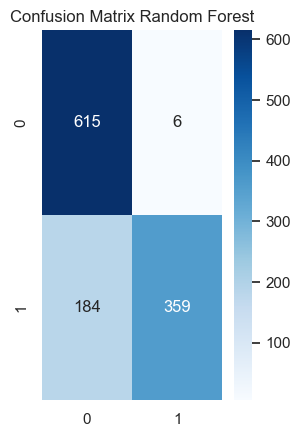

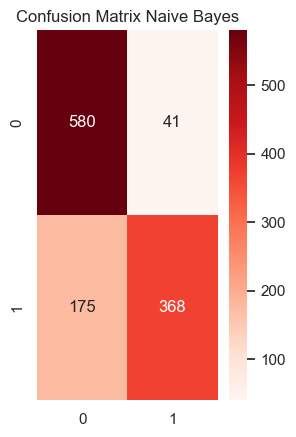

In [49]:
# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,5))
plt.show()
plt.subplot(1,2,1)

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix Random Forest")
plt.show()
plt.subplot(1,2,2)

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Reds"
)

plt.title("Confusion Matrix Naive Bayes")
plt.show()
save_plot("confusion_matrix_compare.png")

Confusion matrix membantu memperlihatkan jenis kesalahan prediksi yang dilakukan model.

Kesalahan yang paling perlu diperhatikan adalah ketika kondisi gangguan diprediksi sebagai normal karena kondisi tersebut dapat menyebabkan gangguan jaringan tidak terdeteksi lebih awal.

<Figure size 600x500 with 0 Axes>

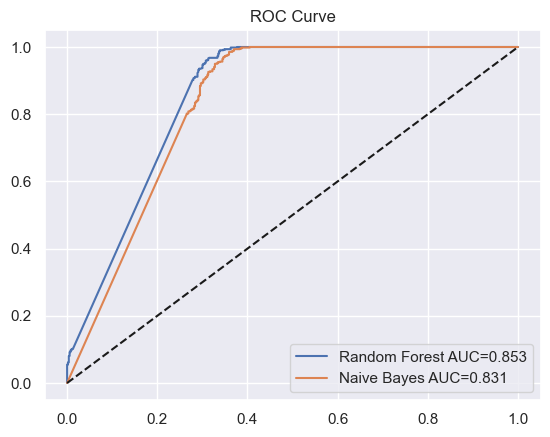

In [50]:
# ROC Curve
gangguan_index = int(le.transform(["gangguan"])[0])

rf_proba = rf.predict_proba(x_test)[:, gangguan_index]
nb_proba = nb.predict_proba(x_test)[:, gangguan_index]

y_test_bin = (
    y_test == gangguan_index
).astype(int)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test_bin,
    rf_proba
)

fpr_nb, tpr_nb, _ = roc_curve(
    y_test_bin,
    nb_proba
)

roc_auc_rf = auc(fpr_rf, tpr_rf)
roc_auc_nb = auc(fpr_nb, tpr_nb)

plt.figure(figsize=(6,5))
plt.show()
plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest AUC={roc_auc_rf:.3f}"
)

plt.plot(
    fpr_nb,
    tpr_nb,
    label=f"Naive Bayes AUC={roc_auc_nb:.3f}"
)

plt.plot([0,1],[0,1],"k--")

plt.legend()

plt.title("ROC Curve")
plt.show()
save_plot("roc_curve.png")

ROC Curve memperlihatkan kemampuan model dalam membedakan antara kondisi normal dan gangguan pada berbagai threshold probabilitas.

Semakin mendekati sudut kiri atas, semakin baik kemampuan model dalam melakukan klasifikasi.

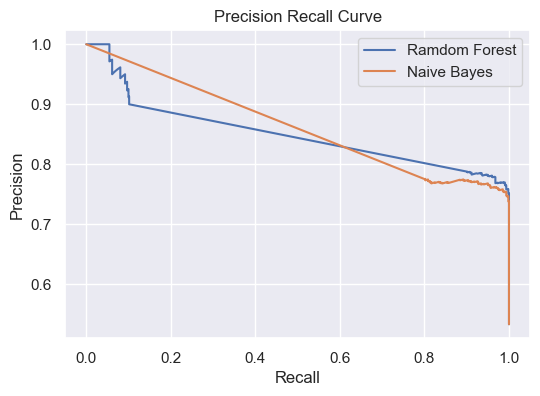

In [51]:
# Precision Recall Curve
prec_rf, rec_rf, _ = precision_recall_curve(
    y_test_bin,
    rf_proba
)

prec_nb, rec_nb, _ = precision_recall_curve(
    y_test_bin,
    nb_proba
)

plt.figure(figsize=(6,4))

plt.plot(
    rec_rf,
    prec_rf,
    label="Ramdom Forest"
)

plt.plot(
    rec_nb,
    prec_nb,
    label="Naive Bayes"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend()

plt.title("Precision Recall Curve")
plt.show()
save_plot("pr_curve.png")

Precision Recall Curve digunakan untuk melihat keseimbangan antara kemampuan model dalam mendeteksi gangguan dan ketepatan prediksi yang dihasilkan.

Visualisasi ini menjadi penting terutama ketika distribusi kelas tidak sepenuhnya seimbang.

### Perbandingan Model

In [52]:
metrics_df = pd.DataFrame({
    "Model": ["Random Forest", "Naive Bayes"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_nb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_nb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_nb)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_nb)
    ]
})

metrics_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.836770,0.983562,0.661142,0.790749
1,Naive Bayes,0.814433,0.899756,0.677716,0.773109


In [53]:
# Export Metrics Summary Ke JSON

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb)
nb_recall = recall_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)

metrics_summary = {
    "rf": {
        "accuracy": float(rf_accuracy),
        "precision": float(rf_precision),
        "recall": float(rf_recall),
        "f1": float(rf_f1),
        "roc_auc": float(roc_auc_rf),
        "pr_auc": float(
            auc(rec_rf, prec_rf)
        )
    },

    "nb": {
        "accuracy": float(nb_accuracy),
        "precision": float(nb_precision),
        "recall": float(nb_recall),
        "f1": float(nb_f1),
        "roc_auc": float(roc_auc_nb),
        "pr_auc": float(
            auc(rec_nb, prec_nb)
        )
    },

    "label_classes": list(le.classes_),

    "feature_names": [
        "bandwidth",
        "latency",
        "packet_loss",
        "uptime"
    ]
}

with open(
    os.path.join(BASE_DIR, "metrics_summary.json"),
    "w"
) as f:

    json.dump(
        metrics_summary,
        f,
        indent=4
    )

print("metrics_summary.json berhasil diperbarui")

metrics_summary.json berhasil diperbarui


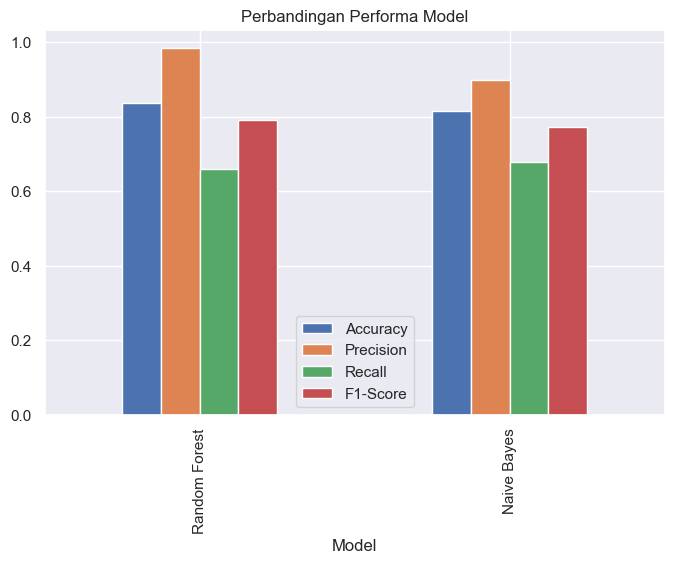

In [54]:
metrics_df.set_index("Model").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Perbandingan Performa Model")
plt.show()
save_plot("model_comparison.png")

Perbandingan performa model menunjukkan bahwa masing-masing algoritma memiliki karakteristik yang berbeda dalam memahami pola data jaringan.

Random Forest cenderung menghasilkan performa yang lebih stabil pada berbagai metrik evaluasi, sedangkan Naive Bayes memiliki kecenderungan menghasilkan recall yang tinggi namun lebih sensitif terhadap distribusi data.

### Learning Curve

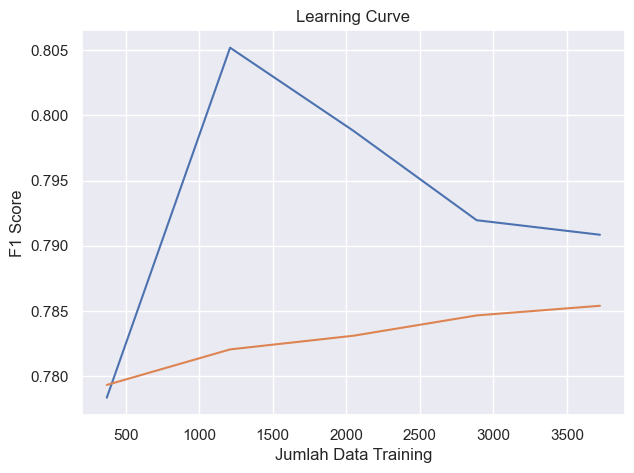

In [55]:
train_sizes, train_scores, val_scores = learning_curve(
    rf,
    x_train,
    y_train,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(7,5))

plt.plot(
    train_sizes,
    train_mean,
    label="Training Score"
)

plt.plot(
    train_sizes,
    val_mean,
    label="Validation Score"
)

plt.xlabel("Jumlah Data Training")
plt.ylabel("F1 Score")

plt.title("Learning Curve")
plt.show()
plt.legend()

save_plot("learning_curve.png")

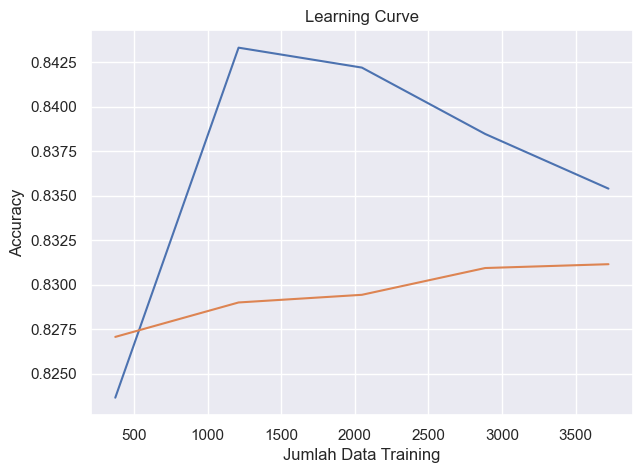

In [60]:
train_sizes, train_scores, val_scores = learning_curve(
    rf,
    x_train,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(7,5))

plt.plot(
    train_sizes,
    train_mean,
    label="Training Score"
)

plt.plot(
    train_sizes,
    val_mean,
    label="Validation Score"
)

plt.xlabel("Jumlah Data Training")
plt.ylabel("Accuracy")

plt.title("Learning Curve")
plt.show()
plt.legend()

save_plot("learning_curve.png")

Learning curve digunakan untuk memahami bagaimana model belajar terhadap data training dan bagaimana kemampuan generalisasinya terhadap data validasi.

Apabila jarak antara kurva training dan validation terlalu jauh, maka model berpotensi mengalami overfitting. Sebaliknya, apabila kedua kurva sama-sama rendah, maka model dapat mengalami underfitting.

Visualisasi ini membantu memastikan bahwa model tidak hanya menghafal data training, tetapi juga mampu memahami pola yang lebih umum pada data jaringan.


### Feature Importances


In [56]:
importance = rf.feature_importances_

fi_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(
    by="Importance",
    ascending=False
)

fi_df

,Feature,Importance
2,packet_loss,0.613456
3,uptime,0.173253
0,bandwidth,0.159624
1,latency,0.053667


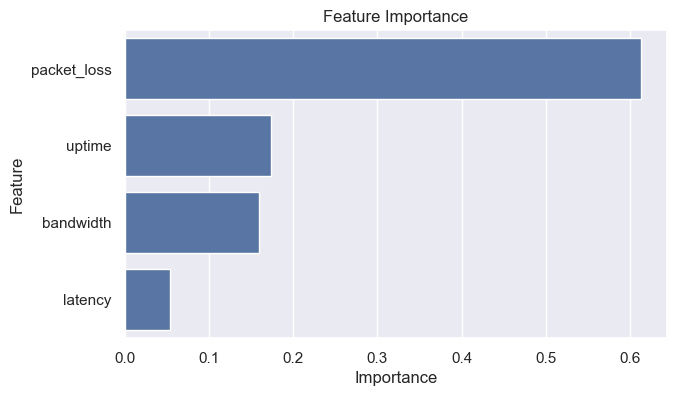

In [57]:
plt.figure(figsize=(7,4))

sns.barplot(
    data=fi_df,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()
save_plot("feature_importance.png")

Feature importance memperlihatkan kontribusi masing-masing parameter jaringan terhadap proses klasifikasi.

Melalui analisis ini dapat diketahui parameter mana yang paling berpengaruh dalam membedakan kondisi normal dan gangguan pada jaringan.

### Menyimpan Model Hasil Training

In [59]:
# Save Model  Hasil Training Menggunakan Joblib 

joblib.dump(
    rf,
    os.path.join(MODELS_DIR, "rf_model.pkl")
)

joblib.dump(
    nb,
    os.path.join(MODELS_DIR, "nb_model.pkl")
)

joblib.dump(
    scaler,
    os.path.join(MODELS_DIR, "scaler.pkl")
)

joblib.dump(
    le,
    os.path.join(MODELS_DIR, "label_encoder.pkl")
)

['c:\\Users\\lenovo\\OneDrive\\Desktop\\Git Uploads\\Prediksi-Machine-Learning\\Supervised Learning\\models\\label_encoder.pkl']